# URL

In [1]:
import pandas as pd
from IPython.display import display

# Cargar los datos
url = "https://raw.githubusercontent.com/jthowinsson/Suicidio_Colombia/main/Presuntos_Suicidios_con_Coor.csv"
df = pd.read_csv(url, encoding="utf-8")

# Guardar nombres originales
nombres_originales = df.columns.tolist()

# Función para limpiar nombres de columnas
def limpiar_nombres(cols):
    cols = cols.astype(str)
    # Quitar tildes
    mapping_tildes = str.maketrans("áéíóúÁÉÍÓÚ", "aeiouAEIOU")
    cols = cols.str.translate(mapping_tildes)
    # A minúsculas
    cols = cols.str.lower()
    # Reemplazar cualquier carácter no alfanumérico por guion bajo
    cols = cols.str.replace(r'[^a-zA-Z0-9]+', '_', regex=True)
    # Limpiar guiones bajos extra al inicio/final
    cols = cols.str.strip('_')
    return cols

# Aplicar limpieza
df.columns = limpiar_nombres(df.columns)

# Guardar nombres limpios
nombres_limpios = df.columns.tolist()

# Crear tabla de comparación
tabla = pd.DataFrame({
    'Nombre original': nombres_originales,
    'Nombre estandarizado': nombres_limpios
})

# Agregar la fuente como fila final (pie de página dentro de la tabla)
fuente = pd.DataFrame([[
    '<em>Fuente: <a href="https://www.datos.gov.co/Justicia-y-Derecho/Presuntos-Suicidios-Colombia-2015-a-2024-Cifras-de/f75u-mirk/about_data" target="_blank">datos.gov.co</a></em>',
    ''
]], columns=['Nombre original', 'Nombre estandarizado'])

tabla_final = pd.concat([tabla, fuente], ignore_index=True)

# Mostrar tabla con estilo (sin fuente en el caption)
display(tabla_final.style
        .set_caption("Mapeo de nombres de columnas y Estandarización")
        .set_table_attributes('style="border-collapse: collapse; width: 100;"')
        .set_properties(**{
            'border': '1px solid #ddd',
            'padding': '10px',
            'font-size': '14px',
            'text-align': 'left'
        })
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '16px'), ('font-weight', 'bold'), ('color', '#333'), ('margin-bottom', '10px')]},
            {'selector': 'th',
             'props': [('background-color', '#1f77b4'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'tr:nth-child(even):not(:last-child)',
             'props': [('background-color', '#f7f7f7')]},
            {'selector': 'tr:last-child',
             'props': [('font-style', 'italic'), ('color', '#555'), ('font-size', '12px'), ('background-color', '#f9f9f9'), ('border-top', '2px solid #eee')]},
            {'selector': 'td, th',
             'props': [('padding', '8px')]}
        ])
        .hide(axis="index")
)

Nombre original,Nombre estandarizado
ID,id
Año del hecho,a_o_del_hecho
Grupo de edad de la victima,grupo_de_edad_de_la_victima
Grupo Mayor Menor de Edad,grupo_mayor_menor_de_edad
Edad judicial,edad_judicial
Ciclo Vital,ciclo_vital
Sexo de la victima,sexo_de_la_victima
Estado Civil,estado_civil
País de Nacimiento de la Víctima,pais_de_nacimiento_de_la_victima
Escolaridad,escolaridad


In [ ]:
print(df.shape) #este es para verificar las dimensiones del DataFrame

(23544, 42)


In [4]:
# 2. INFORMACIÓN GENERAL DEL DATASET
print("\n--- Información general ---")
print(df.info())


--- Información general ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23544 entries, 0 to 23543
Data columns (total 42 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   id                                    23544 non-null  int64  
 1   a_o_del_hecho                         23544 non-null  int64  
 2   grupo_de_edad_de_la_victima           23544 non-null  object 
 3   grupo_mayor_menor_de_edad             23544 non-null  object 
 4   edad_judicial                         23544 non-null  object 
 5   ciclo_vital                           23544 non-null  object 
 6   sexo_de_la_victima                    23544 non-null  object 
 7   estado_civil                          23544 non-null  object 
 8   pais_de_nacimiento_de_la_victima      23544 non-null  object 
 9   escolaridad                           23544 non-null  object 
 10  pertenencia_grupal                    23544 non-null 

In [5]:
# 3. Vista pereliminar de los datos (head)
import pandas as pd

print("--- Primeras filas ---")
print(df.head())

# Configuración pandas para mostrar todas las columnas y todo el ancho
pd.set_option('display.max_columns', 50)
pd.set_option('display.max_colwidth', None)

--- Primeras filas ---
   id  a_o_del_hecho grupo_de_edad_de_la_victima  \
0   1           2015                   (18 a 19)   
1   2           2015                   (25 a 29)   
2   3           2015                   (35 a 39)   
3   4           2015                   (55 a 59)   
4   5           2015                   (45 a 49)   

       grupo_mayor_menor_de_edad edad_judicial         ciclo_vital  \
0  b) Mayores de Edad (>18 años)     (18 a 19)  (18 a 28) Juventud   
1  b) Mayores de Edad (>18 años)     (25 a 28)  (18 a 28) Juventud   
2  b) Mayores de Edad (>18 años)     (35 a 39)   (29 a 59) Adultez   
3  b) Mayores de Edad (>18 años)     (55 a 59)   (29 a 59) Adultez   
4  b) Mayores de Edad (>18 años)     (45 a 49)   (29 a 59) Adultez   

  sexo_de_la_victima estado_civil pais_de_nacimiento_de_la_victima  \
0              Mujer   Soltero(a)                         Colombia   
1             Hombre   Soltero(a)                         Colombia   
2             Hombre  Unión libre

In [7]:
# 9. Contar frecuencias de mecanismos
import pandas as pd
conteo_mecanismos = df["mecanismo_causal"].value_counts()

print(conteo_mecanismos)

mecanismo_causal
Generadores de asfixia          15410
Tóxico                           3829
Proyectil de arma de fuego       2345
Contundente                      1405
Corto punzante                    255
Cortante                          135
Térmico                            80
Por determinar                     35
Caústico                           19
Corto contundente                  15
Agente o mecanismo explosivo        8
Punzante                            5
Eléctrico                           2
Mecanismo o agente explosivo        1
Name: count, dtype: int64


,Frecuencia Absoluta,Frecuencia Porcentual %
sexo_de_la_victima,,
Hombre,18928,80.4
Mujer,4616,19.6


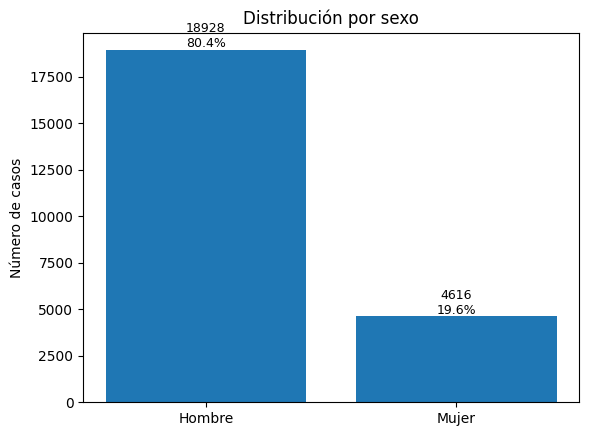

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Detecta la columna de sexo
col_sexo = next((c for c in df.columns if 'sexo' in c.lower()), None)
if col_sexo is None:
    raise ValueError("No encuentro una columna que contenga 'sexo' en su nombre.")

# Tabla n y %
serie = (df[col_sexo].astype(str).str.strip().str.title()
         .replace({'Nan':'Desconocido'}))
vc = serie.value_counts(dropna=False)
pct = (vc / vc.sum() * 100).round(1)
tabla = pd.DataFrame({'Frecuencia Absoluta': vc, 'Frecuencia Porcentual %': pct})
from IPython.display import display
display(tabla)

#Gráfico
fig, ax = plt.subplots()
ax.bar(vc.index, vc.values)
ax.set_title("Distribución por sexo")
ax.set_ylabel("Número de casos")
for i, v in enumerate(vc.values):
    ax.text(i, v, f"{v}\n{pct.iloc[i]}%", ha='center', va='bottom', fontsize=9)
plt.show()

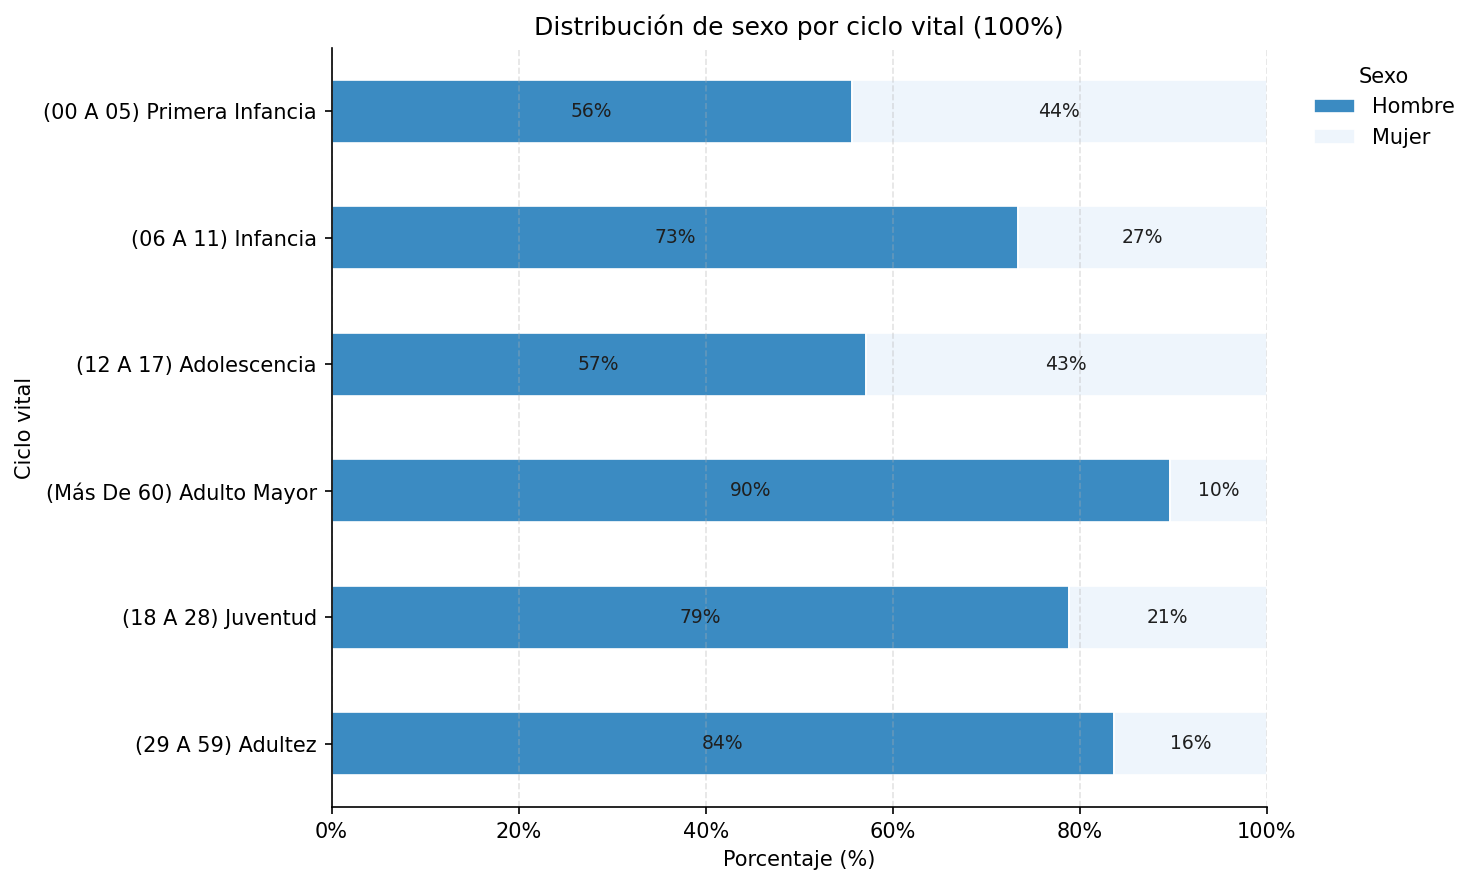

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, PercentFormatter

# === Construir rowpct (100% por ciclo vital) ===
col_sexo = next(c for c in df.columns if 'sexo' in c.lower())
col_ciclo = next(c for c in df.columns if 'ciclo' in c.lower())

sexo = df[col_sexo].astype(str).str.strip().str.title().replace({'Nan':'Desconocido'})
ciclo = df[col_ciclo].astype(str).str.strip().str.title().replace({'Nan':'Desconocido'})

tab = pd.crosstab(ciclo, sexo) # conteos
rowpct = (tab.div(tab.sum(1), axis=0) * 100).round(1) # % por fila
rowpct = rowpct.loc[tab.sum(1).sort_values(ascending=False).index] # ordenar por n

# === Gráfica monocrómica ===
fig, ax = plt.subplots(figsize=(10,6), dpi=150)
cats = rowpct.columns.tolist()
cmap = plt.cm.Blues_r
colors = [cmap(0.35 + 0.6*i/max(1, len(cats)-1)) for i in range(len(cats))]

rowpct.plot(kind='barh', stacked=True, ax=ax, color=colors, edgecolor='white', linewidth=0.8)

ax.set_xlim(0, 100)
ax.xaxis.set_major_locator(MultipleLocator(20))
ax.xaxis.set_major_formatter(PercentFormatter(100, decimals=0))
ax.grid(axis='x', linestyle='--', alpha=0.35)
ax.set_xlabel('Porcentaje (%)'); ax.set_ylabel('Ciclo vital')
ax.set_title('Distribución de sexo por ciclo vital (100%)')
for s in ['top','right']: ax.spines[s].set_visible(False)
ax.legend(title='Sexo', bbox_to_anchor=(1.03,1), loc='upper left', frameon=False)

for i, (_, row) in enumerate(rowpct.iterrows()):
    cum = 0
    for val in row:
        if val >= 3:
            ax.text(cum + val/2, i, f'{val:.0f}%', ha='center', va='center', fontsize=9, color='#1f1f1f')
        cum += val

plt.tight_layout(); plt.show()

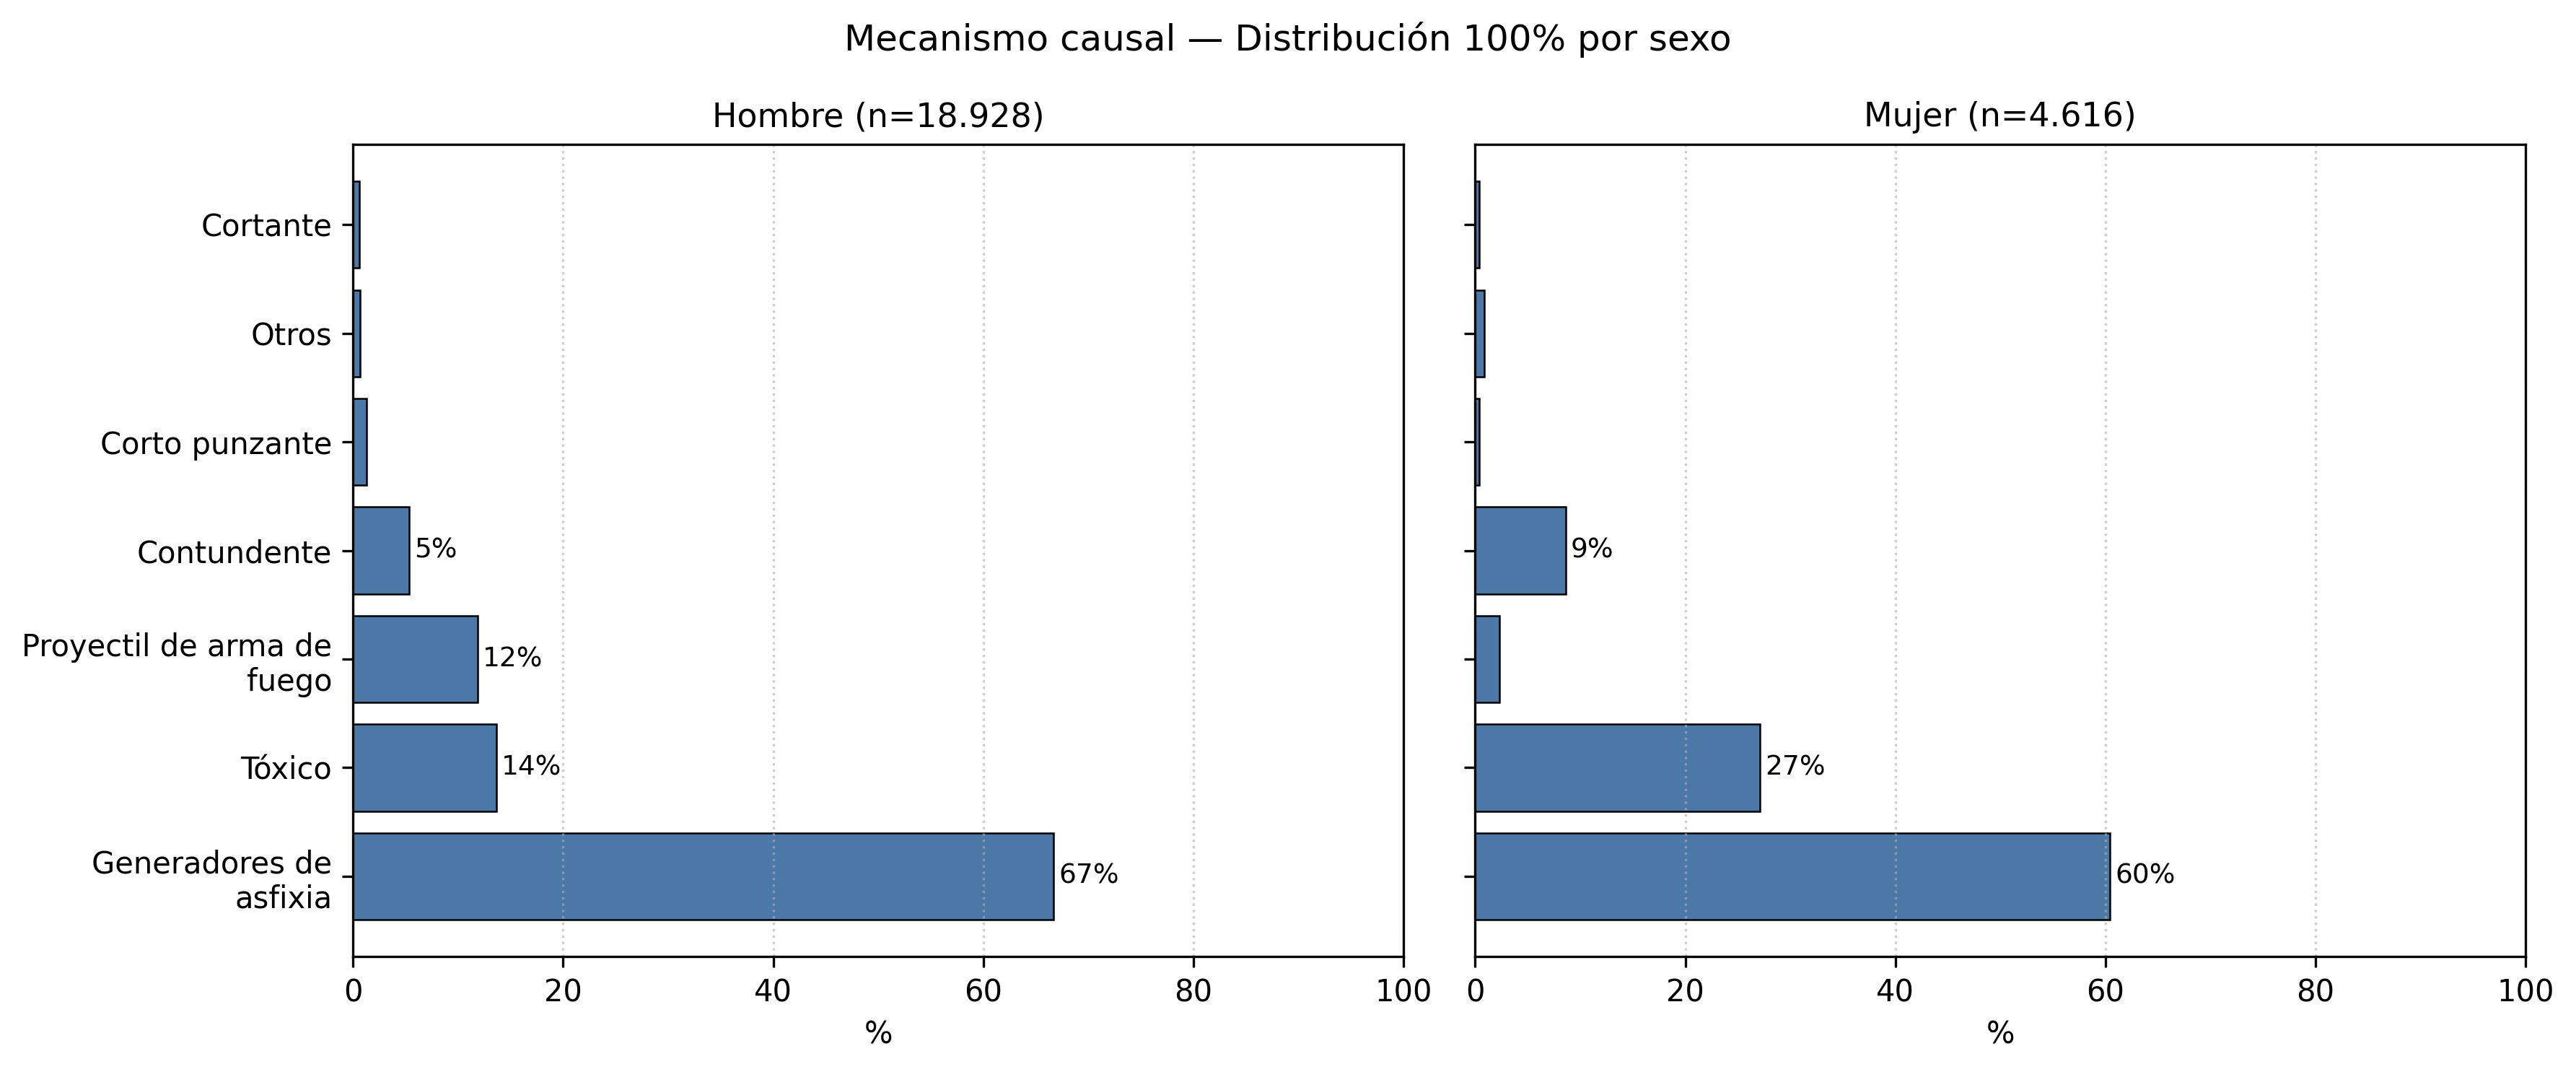

In [11]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, textwrap as tw

COL_MEC = 'mecanismo_causal'
COL_SEX = 'sexo_de_la_victima'
TOP_K = 6

# Limpieza
df_ = df[[COL_SEX, COL_MEC]].dropna().copy()
df_[COL_SEX] = df_[COL_SEX].astype(str).str.strip().str.title()
df_[COL_MEC] = df_[COL_MEC].astype(str).str.strip().replace({'nan':'Falta_dato'})

# Top-K global + Otros
top = df_[COL_MEC].value_counts().index[:TOP_K].tolist()
df_['mec_plot'] = np.where(df_[COL_MEC].isin(top), df_[COL_MEC], 'Otros')

# % por sexo
tab = df_.value_counts([COL_SEX,'mec_plot']).unstack(fill_value=0)
rowpct = tab.div(tab.sum(1), axis=0)*100

# Selecciona los 2 sexos más frecuentes para panel limpio
sexos = tab.sum(1).sort_values(ascending=False).index[:2].tolist()
cats = rowpct.sum(0).sort_values(ascending=False).index.tolist()

fig, axes = plt.subplots(1, len(sexos), figsize=(12,5), dpi=300, sharey=True)
if len(sexos)==1: axes=[axes]

for ax, sx in zip(axes, sexos):
    vals = rowpct.loc[sx, cats]
    y = np.arange(len(cats))
    ax.barh(y, vals.values, color='#4c78a8', edgecolor='black', linewidth=0.6)
    for i,v in enumerate(vals.values):
        if v>=5:
            ax.text(v+0.5, i, f'{v:.0f}%', va='center', ha='left', fontsize=9)
    ax.set_title(f'{sx} (n={int(tab.loc[sx].sum()):,})'.replace(',', '.'), fontsize=11)
    ax.set_xlim(0, 100); ax.set_xlabel('%')
    ax.invert_yaxis()
    ax.grid(axis='x', linestyle=':', alpha=0.6)
axes[0].set_yticks(np.arange(len(cats)))
axes[0].set_yticklabels(["\n".join(tw.wrap(c, 20)) for c in cats], fontsize=10)
fig.suptitle('Mecanismo causal — Distribución 100% por sexo', fontsize=12)
plt.tight_layout()
# plt.savefig('mecanismo_por_sexo_panel.pdf', bbox_inches='tight')
plt.show()

In [13]:
# =========================
# Mapa + Tablas PRO con tus datos (sin GeoJSON)
# =========================
import re, unicodedata
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.io as pio

# ---------- Render del mapa ----------
try:
    pio.renderers.default = "notebook_connected"
except Exception:
    pio.renderers.default = "browser"

# ---------- 1) Detecta columna de departamento ----------
# 0. Detectar automáticamente la columna de departamento (sin prints)
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

dept_col_candidates = [
    'Departamento del hecho DANE','Depto_Nom','Departamento_ocurrencia',
    'Departamento','DEPARTAMENTO','Depto','departamento'
]

dept_col = next((c for c in dept_col_candidates if c in df.columns), None)
if dept_col is None:
    matches = [c for c in df.columns if 'depart' in c.lower()]
    if not matches:
        raise KeyError("No se encontró columna de departamento.")
    dept_col = matches[0]


# ---------- 2) Verifica columnas lat/lon de tu base ----------
assert {'latitud','longitud'}.issubset(df.columns), "Faltan columnas 'latitud' y 'longitud'"

# ---------- 3) Limpieza y agregación ----------
# Excluye 'Sin información' si existe
df_clean = df[df[dept_col].astype(str).ne("Sin información")].copy()

# Agrega por departamento: centroides desde TUS coordenadas y conteo
map_data = (df_clean.groupby(dept_col, dropna=False)
            .agg(lat=('latitud','mean'),
                 lon=('longitud','mean'),
                 casos=(dept_col,'size'))
            .reset_index())

# Etiquetas y tamaño de burbuja
def _title(s): 
    s = str(s).strip()
    # normaliza uso de mayúsculas en preposiciones frecuentes
    s = re.sub(r'\b(de|del|la|y)\b', lambda m: m.group(0).lower(), s.title(), flags=re.I)
    return s

map_data['dept_clean'] = map_data[dept_col].map(_title)
map_data['size_norm'] = np.log1p(map_data['casos']) * 6

# ---------- 4) Mapa (usa scatter_map si está disponible; si no, fallback a scatter_mapbox) ----------
try:
    fig = px.scatter_map(
        map_data,
        lat="lat", lon="lon",
        size="size_norm", size_max=28,
        color="casos", color_continuous_scale="Viridis",
        hover_name="dept_clean",
        hover_data={"casos":":,", "lat":False, "lon":False, "size_norm":False},
        zoom=5, center=dict(lat=4.6, lon=-74.1),
        map_style="open-street-map",
        title=f"Presuntos suicidios por departamento — Total: {map_data['casos'].sum():,} casos"
    )
except Exception:
    fig = px.scatter_mapbox(
        map_data,
        lat="lat", lon="lon",
        size="size_norm", size_max=28,
        color="casos", color_continuous_scale="Viridis",
        hover_name="dept_clean",
        hover_data={"casos":":,", "lat":False, "lon":False, "size_norm":False},
        zoom=5, center=dict(lat=4.6, lon=-74.1),
        mapbox_style="open-street-map",
        title=f"Presuntos suicidios por departamento — Total: {map_data['casos'].sum():,} casos"
    )

fig.update_layout(margin=dict(l=0,r=0,t=60,b=0), height=700, width=950)
fig.show()

# ---------- 5) Tablas PRO ----------
# Tabla completa ordenada + participación y ranking
tbl = (map_data
       .assign(Participación=lambda d: d["casos"] / d["casos"].sum())
       .sort_values("casos", ascending=False, ignore_index=True))
tbl.insert(0, "Rank", tbl.index + 1)
tbl = tbl.rename(columns={dept_col: "Departamento", "casos": "Casos"})

estilo_tbl = (tbl.style
    .format({"Casos": "{:,}", "Participación": "{:.1%}"})
    .hide(axis="index")
    .bar(subset=["Casos"], color="#b3d1ff")
    .background_gradient(subset=["Participación"], cmap="YlOrRd")
    .set_properties(**{"text-align": "left"})
    .set_table_styles([{"selector": "th", "props": [("text-align", "left"), ("font-weight", "500")]}])
)
display(estilo_tbl)

# Top 10 compacto
top10 = tbl.head(10).copy()
estilo_top10 = (top10.style
    .format({"Casos": "{:,}", "Participación": "{:.1%}"})
    .hide(axis="index")
    .set_properties(**{"text-align": "left"})
    .set_table_styles([{"selector": "th", "props": [("text-align", "left"), ("font-weight", "500")]}])
)
display(estilo_top10)

# Resumen numérico
resumen = pd.DataFrame({
    "Total casos": [tbl["Casos"].sum()],
    "N departamentos": [len(tbl)],
    "Promedio casos/depto": [round(tbl["Casos"].mean(), 1)],
    "Mediana": [int(tbl["Casos"].median())]
})
display(resumen.style.format("{:,}").hide(axis="index"))

Rank,Departamento,lat,lon,Casos,dept_clean,size_norm,Participación
1,Antioquia,6.384135,-75.591164,"3,913",Antioquia,49.633891,16.6%
2,"Bogotá, D.C.",4.649251,-74.106992,"3,373","Bogotá, D.C.",48.743126,14.3%
3,Valle del Cauca,3.703794,-76.404540,"2,060",Valle del Cauca,45.785679,8.8%
4,Cundinamarca,4.738987,-74.229318,"1,446",Cundinamarca,43.663486,6.1%
5,Santander,6.900185,-73.273514,"1,140",Santander,42.237962,4.8%
6,Tolima,4.395348,-75.108298,909,Tolima,40.880668,3.9%
7,Norte de Santander,8.008635,-72.782842,837,Norte de Santander,40.386109,3.6%
8,Atlántico,10.904340,-74.828031,809,Atlántico,40.182205,3.4%
9,Nariño,1.270181,-77.584478,755,Nariño,39.768248,3.2%
10,Huila,2.480193,-75.609458,736,Huila,39.615527,3.1%


Rank,Departamento,lat,lon,Casos,dept_clean,size_norm,Participación
1,Antioquia,6.384135,-75.591164,"3,913",Antioquia,49.633891,16.6%
2,"Bogotá, D.C.",4.649251,-74.106992,"3,373","Bogotá, D.C.",48.743126,14.3%
3,Valle del Cauca,3.703794,-76.404540,"2,060",Valle del Cauca,45.785679,8.8%
4,Cundinamarca,4.738987,-74.229318,"1,446",Cundinamarca,43.663486,6.1%
5,Santander,6.900185,-73.273514,"1,140",Santander,42.237962,4.8%
6,Tolima,4.395348,-75.108298,909,Tolima,40.880668,3.9%
7,Norte de Santander,8.008635,-72.782842,837,Norte de Santander,40.386109,3.6%
8,Atlántico,10.904340,-74.828031,809,Atlántico,40.182205,3.4%
9,Nariño,1.270181,-77.584478,755,Nariño,39.768248,3.2%
10,Huila,2.480193,-75.609458,736,Huila,39.615527,3.1%


Total casos,N departamentos,Promedio casos/depto,Mediana
"23,541",33,713.4,536
